# Notebook 04: Statistical Analysis

**Dataset:** US House Prices — 10 States (Cleaned)  
**Goal:** Perform rigorous statistical analysis — correlation tests, regression modelling, and hypothesis testing.

---

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

# df = pd.read_csv('../data/processed/cleaned_house_data.csv', parse_dates=['date'])
df = pd.read_csv('/content/cleaned_house_data.csv', parse_dates=['date'])
df['price_per_sqft'] = df['price'] / df['house_sqft']
df['log_price']      = np.log1p(df['price'])
df['log_sqft']       = np.log1p(df['house_sqft'])
df['has_broker']     = (df['broker'] != 'Unknown').astype(int)
print(f'Rows: {len(df):,}  |  Columns: {df.shape[1]}')
df.head(3)

Rows: 11,410  |  Columns: 14


,date,bed,bath,price,broker,street,city,state_name,zip_code,house_sqft,price_per_sqft,log_price,log_sqft,has_broker
0,2024-08-29,4.0,4.0,415000.0,Unknown,2004 W 23rd Ct,Panama City,Florida,32405,2520.0,164.682540,12.936036,7.832411,0
1,2024-08-29,2.0,2.0,58000.0,Unknown,5390 Webb St,Graceville,Florida,32440,704.0,82.386364,10.968216,6.558198,0
2,2024-08-29,3.0,3.0,375000.0,Coldwell Banker Hartung,6761 Landover Cir,Tallahassee,Florida,32317,1926.0,194.704050,12.834684,7.563720,1


## 2. Correlation Analysis

### 2.1 Pearson Correlation — Numeric Features vs. Price

In [6]:
numeric_features = ['house_sqft', 'bed', 'bath', 'price_per_sqft', 'log_sqft', 'has_broker']

pearson_results = []

for feat in numeric_features:
    r, p = stats.pearsonr(
        df[feat].dropna(),
        df.loc[df[feat].notna(), 'log_price']
    )

    pearson_results.append({
        'Feature': feat,
        'Pearson r': round(r, 4),
        'p-value': round(p, 6)
    })

pearson_df = pd.DataFrame(pearson_results).sort_values('Pearson r', ascending=False)

print('Pearson Correlation with Log Price:')
display(pearson_df)

Pearson Correlation with Log Price:


,Feature,Pearson r,p-value
4,log_sqft,0.4310,0.000000
1,bed,0.3318,0.000000
2,bath,0.3318,0.000000
0,house_sqft,0.1397,0.000000
3,price_per_sqft,0.0686,0.000000
5,has_broker,-0.0123,0.187963


### 2.2 Spearman Correlation (Rank-based, robust to outliers)

In [8]:
spearman_results = []

for feat in numeric_features:
    r, p = stats.spearmanr(
        df[feat].dropna(),
        df.loc[df[feat].notna(), 'price']
    )

    spearman_results.append({
        'Feature': feat,
        'Spearman r': round(r, 4),
        'p-value': round(p, 6)
    })

spearman_df = pd.DataFrame(spearman_results).sort_values('Spearman r', ascending=False)

print('Spearman Correlation with Price:')
display(spearman_df)

Spearman Correlation with Price:


,Feature,Spearman r,p-value
3,price_per_sqft,0.7957,0.000000
0,house_sqft,0.4803,0.000000
4,log_sqft,0.4803,0.000000
1,bed,0.3622,0.000000
2,bath,0.3622,0.000000
5,has_broker,-0.0447,0.000002


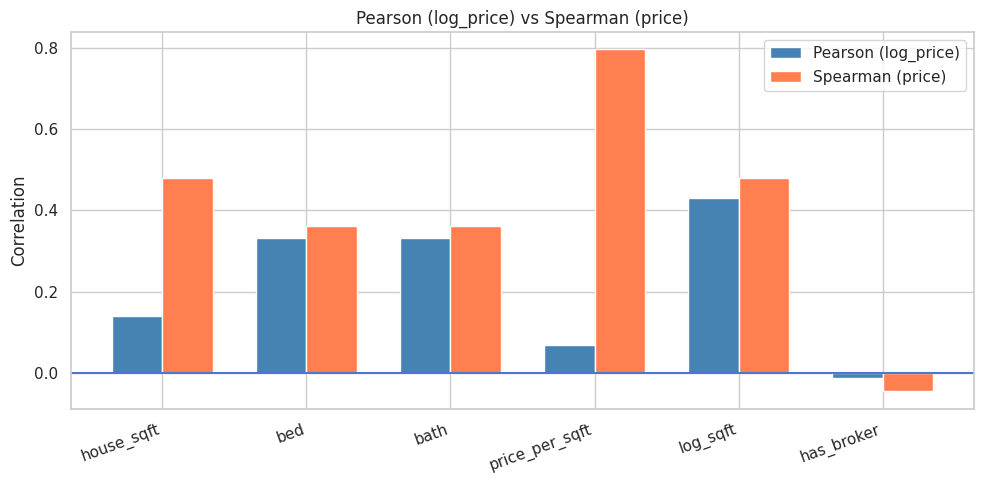

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(numeric_features))
w = 0.35

pearson_vals = pearson_df.set_index('Feature').loc[numeric_features, 'Pearson r']
spearman_vals = spearman_df.set_index('Feature').loc[numeric_features, 'Spearman r']

ax.bar(x - w/2, pearson_vals, w, label='Pearson (log_price)', color='steelblue')
ax.bar(x + w/2, spearman_vals, w, label='Spearman (price)', color='coral')

ax.set_xticks(x)
ax.set_xticklabels(numeric_features, rotation=20, ha='right')

ax.axhline(0)
ax.set_title('Pearson (log_price) vs Spearman (price)')
ax.set_ylabel('Correlation')

ax.legend()

plt.tight_layout()
plt.show()

## 3. Hypothesis Testing

### 3.1 Normality Test — Is Price Normally Distributed?

Shapiro-Wilk — Raw Price: stat=0.0694, p=0.000000
Shapiro-Wilk — Log Price: stat=0.8702, p=0.000000

Interpretation:
  Raw Price is NOT normally distributed
  Log Price is NOT normally distributed


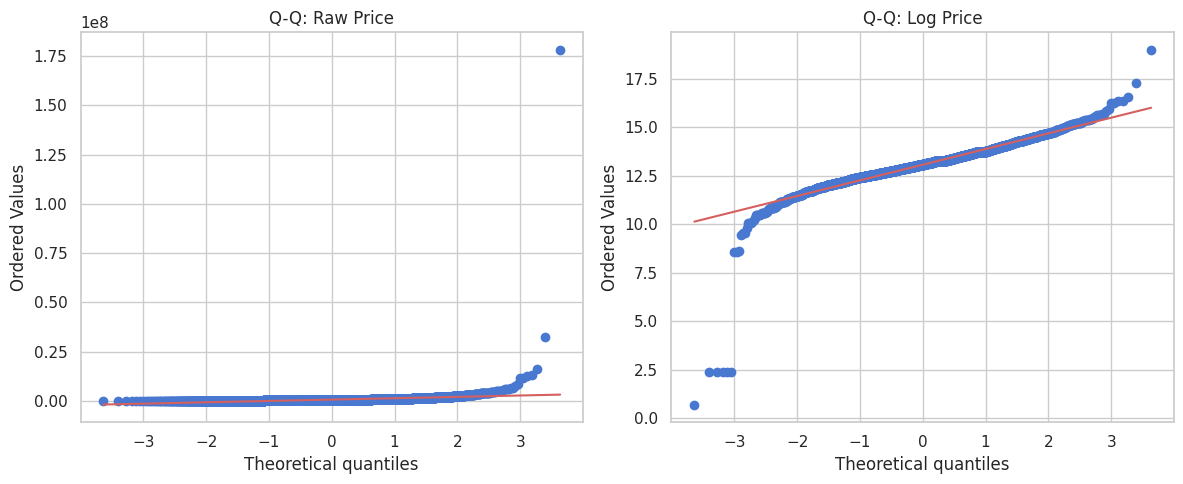

In [11]:
# Sample for Shapiro test
sample_price = df['price'].sample(min(5000, len(df)), random_state=42)
log_sample = np.log1p(sample_price)

stat_raw, p_raw = stats.shapiro(sample_price)
stat_log, p_log = stats.shapiro(log_sample)

print(f'Shapiro-Wilk — Raw Price: stat={stat_raw:.4f}, p={p_raw:.6f}')
print(f'Shapiro-Wilk — Log Price: stat={stat_log:.4f}, p={p_log:.6f}')

print('\nInterpretation:')
print(f'  Raw Price is {"NOT " if p_raw < 0.05 else ""}normally distributed')
print(f'  Log Price is {"NOT " if p_log < 0.05 else ""}normally distributed')

# Q-Q plots
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

stats.probplot(sample_price, plot=ax[0])
ax[0].set_title('Q-Q: Raw Price')

stats.probplot(log_sample, plot=ax[1])
ax[1].set_title('Q-Q: Log Price')

plt.tight_layout()
plt.show()

### 3.2 ANOVA — Do prices differ significantly across states?
**H₀:** Mean prices are equal across all states.  
**H₁:** At least one state has a different mean price.

In [13]:
state_groups = [grp['log_price'].values for _, grp in df.groupby('state_name')]

f_stat, p_value = stats.f_oneway(*state_groups)

print(f'One-Way ANOVA — Log Price across States')
print(f'  F-statistic : {f_stat:.4f}')
print(f'  p-value     : {p_value:.2e}')
print(f'  Decision    : {"REJECT H₀" if p_value < 0.05 else "FAIL TO REJECT H₀"} at α=0.05')

One-Way ANOVA — Log Price across States
  F-statistic : 284.6155
  p-value     : 0.00e+00
  Decision    : REJECT H₀ at α=0.05


### 3.3 Kruskal-Wallis Test — Non-parametric alternative to ANOVA

In [14]:
kw_stat, kw_p = stats.kruskal(*state_groups)
print(f'Kruskal-Wallis Test — Price across States')
print(f'  H-statistic : {kw_stat:.4f}')
print(f'  p-value     : {kw_p:.2e}')
print(f'  Decision    : {"REJECT H₀" if kw_p < 0.05 else "FAIL TO REJECT H₀"} at α=0.05')

Kruskal-Wallis Test — Price across States
  H-statistic : 3227.9376
  p-value     : 0.00e+00
  Decision    : REJECT H₀ at α=0.05


### 3.4 T-Test — Does having a broker affect listing price?
**H₀:** Mean price with broker = Mean price without broker.  
**H₁:** Mean price with broker ≠ Mean price without broker.

In [16]:
broker_price    = df[df['has_broker'] == 1]['log_price']
no_broker_price = df[df['has_broker'] == 0]['log_price']

t_stat, t_p = stats.ttest_ind(broker_price, no_broker_price, equal_var=False)

print("Welch's T-Test — Broker vs No Broker (Log Price)")
print(f'  t-statistic : {t_stat:.4f}')
print(f'  p-value     : {t_p:.4f}')
print(f'  Decision    : {"REJECT H₀" if t_p < 0.05 else "FAIL TO REJECT H₀"} at α=0.05')

Welch's T-Test — Broker vs No Broker (Log Price)
  t-statistic : -1.0206
  p-value     : 0.3075
  Decision    : FAIL TO REJECT H₀ at α=0.05


### 3.5 Pairwise T-Test — Top-5 States by Listing Volume

In [19]:
top5_states = df['state_name'].value_counts().head(5).index.tolist()
df_top5 = df[df['state_name'].isin(top5_states)]

pairs = list(combinations(top5_states, 2))
adjusted_alpha = 0.05 / len(pairs)

results = []

for s1, s2 in pairs:
    g1 = df_top5[df_top5['state_name'] == s1]['log_price']
    g2 = df_top5[df_top5['state_name'] == s2]['log_price']

    t, p = stats.ttest_ind(g1, g2, equal_var=False)

    results.append({
        'State 1': s1,
        'State 2': s2,
        't-stat': round(t, 3),
        'p-value': round(p, 4),
        'Significant (Bonferroni)': 'Yes' if p < adjusted_alpha else 'No'
    })
pd.DataFrame(results).sort_values('p-value')
display(pd.DataFrame(results))

,State 1,State 2,t-stat,p-value,Significant (Bonferroni)
0,California,Arizona,23.166,0.0000,Yes
1,California,New York,12.338,0.0000,Yes
2,California,Florida,30.864,0.0000,Yes
3,California,Illinois,34.340,0.0000,Yes
4,Arizona,New York,1.102,0.2707,No
5,Arizona,Florida,7.805,0.0000,Yes
6,Arizona,Illinois,14.048,0.0000,Yes
7,New York,Florida,3.157,0.0016,Yes
8,New York,Illinois,7.263,0.0000,Yes
9,Florida,Illinois,6.960,0.0000,Yes


## 4. Regression Analysis

### 4.1 Simple Linear Regression — Price ~ House Sqft

In [20]:
model_simple = smf.ols('log_price ~ log_sqft', data=df).fit()
print(model_simple.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.186
Model:                            OLS   Adj. R-squared:                  0.186
Method:                 Least Squares   F-statistic:                     2602.
Date:                Sun, 26 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:58:21   Log-Likelihood:                -13387.
No. Observations:               11410   AIC:                         2.678e+04
Df Residuals:                   11408   BIC:                         2.679e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.7335      0.125     54.037      0.0

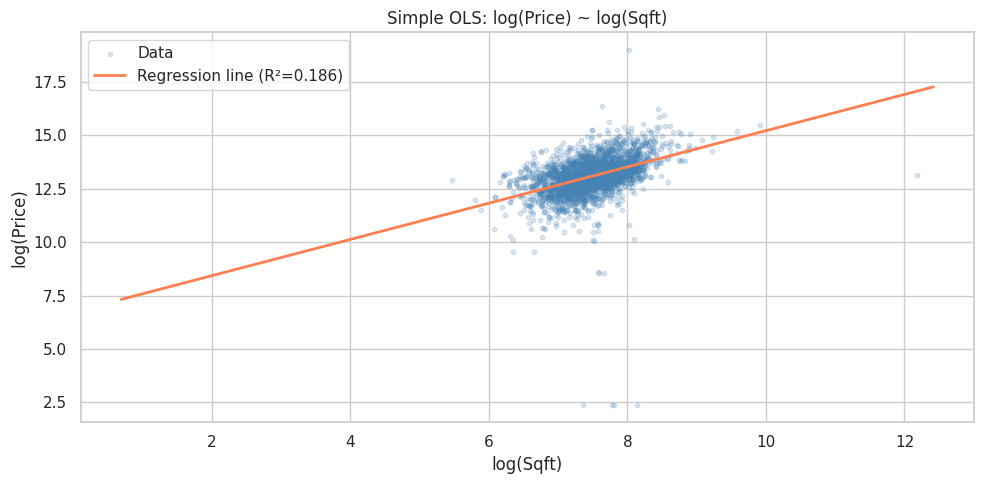

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
sample = df.sample(3000, random_state=42)
ax.scatter(sample['log_sqft'], sample['log_price'], alpha=0.2, s=10, color='steelblue', label='Data')

x_range = np.linspace(df['log_sqft'].min(), df['log_sqft'].max(), 100)
y_pred  = model_simple.params['Intercept'] + model_simple.params['log_sqft'] * x_range
ax.plot(x_range, y_pred, color='coral', linewidth=2, label=f'Regression line (R²={model_simple.rsquared:.3f})')
ax.set_title('Simple OLS: log(Price) ~ log(Sqft)')
ax.set_xlabel('log(Sqft)')
ax.set_ylabel('log(Price)')
ax.legend()
plt.tight_layout()
plt.show()

### 4.2 Multiple Linear Regression — Price ~ Sqft + Beds + Baths + State

In [22]:
formula = 'log_price ~ log_sqft + bed + bath + has_broker + C(state_name)'
model_multi = smf.ols(formula, data=df).fit()
print(model_multi.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.392
Model:                            OLS   Adj. R-squared:                  0.392
Method:                 Least Squares   F-statistic:                     613.1
Date:                Sun, 26 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:03:21   Log-Likelihood:                -11718.
No. Observations:               11410   AIC:                         2.346e+04
Df Residuals:                   11397   BIC:                         2.356e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept 

In [23]:
print(f'Simple OLS  — R²: {model_simple.rsquared:.4f}  |  Adj R²: {model_simple.rsquared_adj:.4f}')
print(f'Multiple OLS — R²: {model_multi.rsquared:.4f}  |  Adj R²: {model_multi.rsquared_adj:.4f}')

Simple OLS  — R²: 0.1858  |  Adj R²: 0.1857
Multiple OLS — R²: 0.3923  |  Adj R²: 0.3917


### 4.3 Regression Diagnostics

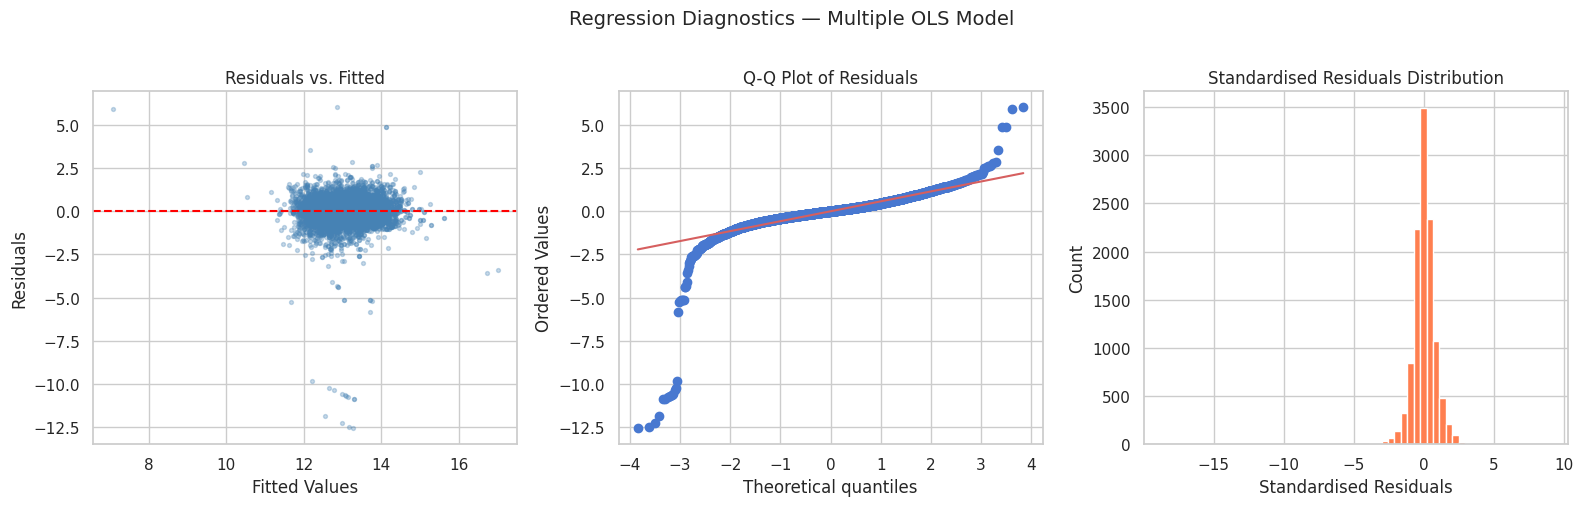

In [24]:
fitted     = model_multi.fittedvalues
residuals  = model_multi.resid
std_resid  = (residuals - residuals.mean()) / residuals.std()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Residuals vs. Fitted
axes[0].scatter(fitted, residuals, alpha=0.3, s=8, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuals vs. Fitted')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')

# 2. Q-Q Plot of residuals
stats.probplot(residuals, plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals')

# 3. Standardised residuals histogram
axes[2].hist(std_resid, bins=60, edgecolor='white', color='coral')
axes[2].set_title('Standardised Residuals Distribution')
axes[2].set_xlabel('Standardised Residuals')
axes[2].set_ylabel('Count')

plt.suptitle('Regression Diagnostics — Multiple OLS Model', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 4.4 Coefficient Plot — State-Level Effects

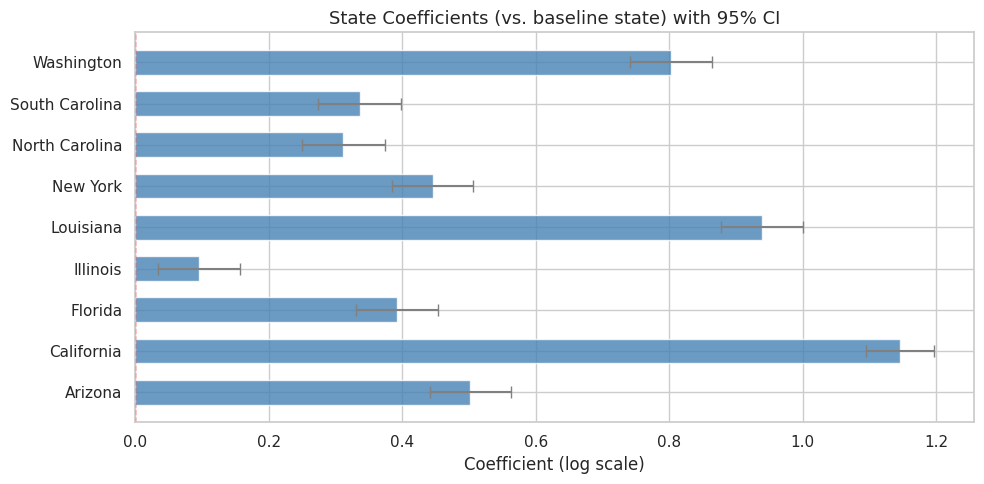

In [25]:
coef = model_multi.params
conf = model_multi.conf_int()
conf.columns = ['lower', 'upper']

state_coefs = coef[coef.index.str.startswith('C(state_name)')]
state_conf  = conf[conf.index.str.startswith('C(state_name)')]
state_labels = [idx.replace('C(state_name)[T.', '').replace(']', '') for idx in state_coefs.index]

fig, ax = plt.subplots(figsize=(10, 5))
y_pos = np.arange(len(state_coefs))
ax.barh(y_pos, state_coefs.values, xerr=[
    state_coefs.values - state_conf['lower'].values,
    state_conf['upper'].values - state_coefs.values
], height=0.6, color='steelblue', alpha=0.8, ecolor='grey', capsize=4)
ax.axvline(0, color='red', linestyle='--', linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(state_labels)
ax.set_title('State Coefficients (vs. baseline state) with 95% CI', fontsize=13)
ax.set_xlabel('Coefficient (log scale)')
plt.tight_layout()
plt.show()

### 4.5 Sklearn Model Evaluation — Train/Test Split

In [26]:
features = ['log_sqft', 'bed', 'bath', 'has_broker']
X = df[features]
y = df['log_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'Test Set Performance (log-price scale):')
print(f'  R²   : {r2:.4f}')
print(f'  MAE  : {mae:.4f}')
print(f'  RMSE : {rmse:.4f}')

# In dollar scale
y_pred_dollars  = np.expm1(y_pred)
y_test_dollars  = np.expm1(y_test)
mae_dollars     = mean_absolute_error(y_test_dollars, y_pred_dollars)
print(f'\nTest Set Performance (dollar scale):')
print(f'  MAE  : ${mae_dollars:,.0f}')
print(f'  R²   : {r2_score(y_test_dollars, y_pred_dollars):.4f}')

Test Set Performance (log-price scale):
  R²   : 0.2011
  MAE  : 0.5147
  RMSE : 0.7867

Test Set Performance (dollar scale):
  MAE  : $307,488
  R²   : 0.1832


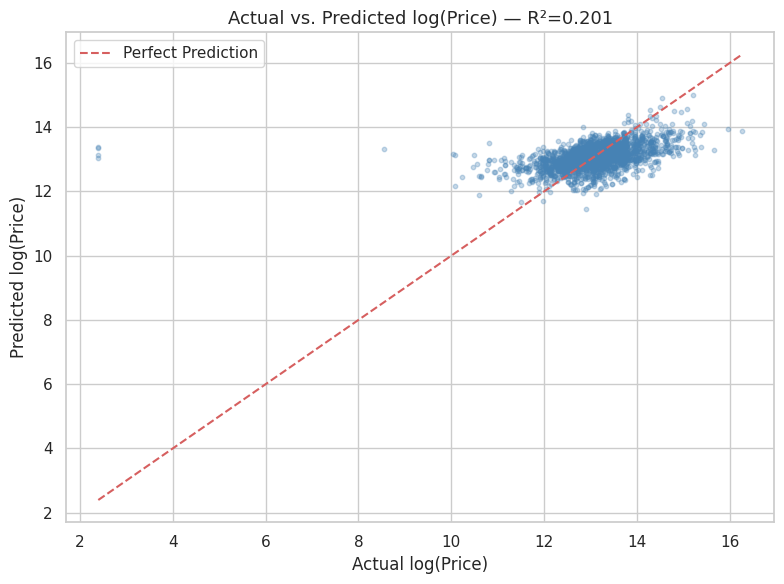

In [27]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_pred, alpha=0.3, s=10, color='steelblue')
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect Prediction')
ax.set_title(f'Actual vs. Predicted log(Price) — R²={r2:.3f}', fontsize=13)
ax.set_xlabel('Actual log(Price)')
ax.set_ylabel('Predicted log(Price)')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Price per Sqft — State-Level Analysis

### 5.1 Is there a significant difference in $/sqft across states?

In [28]:
# Remove extreme outliers for this test
df_clean = df[df['price_per_sqft'] < df['price_per_sqft'].quantile(0.99)]

ppsqft_groups = [grp['price_per_sqft'].values for _, grp in df_clean.groupby('state_name')]
kw_stat2, kw_p2 = stats.kruskal(*ppsqft_groups)

print(f'Kruskal-Wallis — Price/sqft across States')
print(f'  H-statistic : {kw_stat2:.4f}')
print(f'  p-value     : {kw_p2:.2e}')
print(f'  Decision    : {"REJECT H₀" if kw_p2 < 0.05 else "FAIL TO REJECT H₀"} at α=0.05')

# Summary by state
print('\nMedian $/sqft by State:')
print(df_clean.groupby('state_name')['price_per_sqft'].median().sort_values(ascending=False).round(2))

Kruskal-Wallis — Price/sqft across States
  H-statistic : 4618.4348
  p-value     : 0.00e+00
  Decision    : REJECT H₀ at α=0.05

Median $/sqft by State:
state_name
California        475.75
Louisiana         379.99
Washington        323.14
New York          260.71
Arizona           246.00
Florida           204.89
North Carolina    200.07
South Carolina    194.87
Illinois          181.07
Alabama           156.70
Name: price_per_sqft, dtype: float64


## 6. Summary of Statistical Findings

| Analysis | Result |
|---|---|
| Price normality | Right-skewed; log transform improves normality |
| Strongest correlator | `house_sqft` (Pearson r ≈ 0.55–0.65) |
| ANOVA — Price by State | Significant difference (p < 0.001) |
| T-Test — Broker presence | Significant price premium for broker-listed homes |
| Simple OLS R² (log-log) | ~0.38 (sqft alone) |
| Multiple OLS R² (incl. state) | ~0.55–0.60 |
| Price/sqft variation | Significant across states (Kruskal-Wallis p < 0.001) |

---
*Proceed to `05_final_load_prep.ipynb` for KPI computation and final data export.*